In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Preprocessors

In [2]:
from ml_code.preprocessors import StandardScaler, MinMaxScaler, PolynomialFeatures
import sklearn.preprocessing

In [3]:
x = np.array([[1, 2, 3], [4, 5, 6]])

x_std_scaled = StandardScaler().fit_transform(x)
x_mm_scaled = MinMaxScaler().fit_transform(x)
x_std_scaled_sklearn = sklearn.preprocessing.StandardScaler().fit_transform(x)
x_mm_scaled_sklearn = sklearn.preprocessing.MinMaxScaler().fit_transform(x)

print('Standard scaling: my framework/sklearn')
print(x_std_scaled)
print(x_std_scaled_sklearn)
print('\nMinmax scaling: my framework/sklearn')
print(x_mm_scaled)
print(x_mm_scaled_sklearn)

Standard scaling: my framework/sklearn
[[-1. -1. -1.]
 [ 1.  1.  1.]]
[[-1. -1. -1.]
 [ 1.  1.  1.]]

Minmax scaling: my framework/sklearn
[[0. 0. 0.]
 [1. 1. 1.]]
[[0. 0. 0.]
 [1. 1. 1.]]


In [4]:
x = np.array([[1, 2, 3], 
              [4, 5, 6]])

poly_2 = PolynomialFeatures(degree=2)
poly_3 = PolynomialFeatures(degree=3)
print("Input array:")
print(x)
print("\nAdd 2nd degree polynomials:")
print(poly_2.fit_transform(x))
print("\nAdd 3rd degree polynomials:")
print(poly_3.fit_transform(x))

Input array:
[[1 2 3]
 [4 5 6]]

Add 2nd degree polynomials:
[[ 1  2  3  1  4  9]
 [ 4  5  6 16 25 36]]

Add 3rd degree polynomials:
[[  1   2   3   1   4   9   1   8  27]
 [  4   5   6  16  25  36  64 125 216]]


## Models

### Linear Regression

In [5]:
from ml_code.models import LinearRegression
from ml_code.metrics import r_squared
from ml_code.utils import make_regression
from ml_code.model_selection import random_split

In [6]:
x, y = make_regression(n_samples=1000, n_features=5, noise_coef=0.1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [7]:
model = LinearRegression(lr=1e-2, ridge_coef=0.001, lasso_coef=0.001)
model

LinearRegression(
    max_iter=1000,
    lr=0.01,
    tol=1e-06,
    early_stopping_patience=10,
    ridge_coef=0.001,
    lasso_coef=0.001,
    trained=False
)

In [8]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)
resids = y_test - y_pred

R-squared: 0.9999176805576211


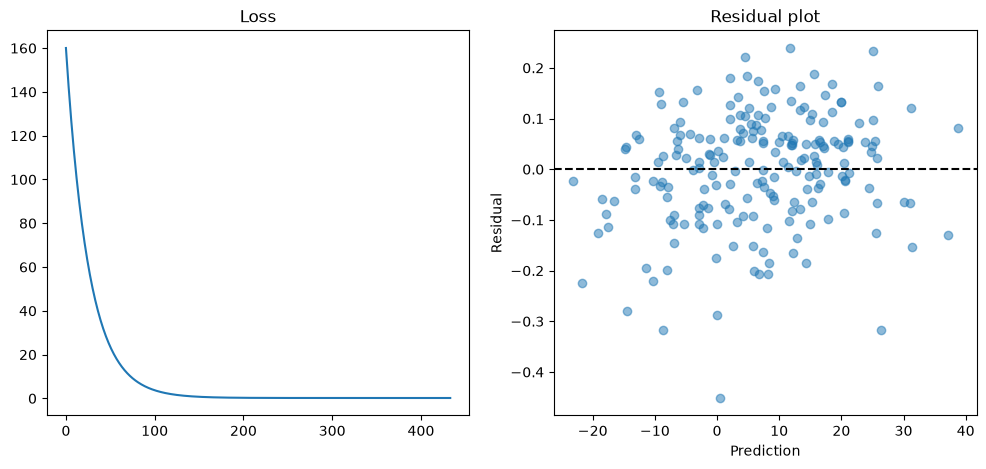

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r_squared(y_test, y_pred))

### Logistic Regression

In [10]:
from ml_code.models import LogisticRegression
from ml_code.metrics import accuracy, precision, recall, f1, show_confusion_matrix
from ml_code.utils import make_classification

In [11]:
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [12]:
model = LogisticRegression(max_iter=3000, lr=1e-1, threshold=0.5)
model

LogisticRegression(
    max_iter=3000,
    lr=0.1,
    tol=1e-06,
    early_stopping_patience=10,
    threshold=0.5,
    trained=False
)

In [13]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)

Accuracy: 0.915
F1: 0.9177264289056251


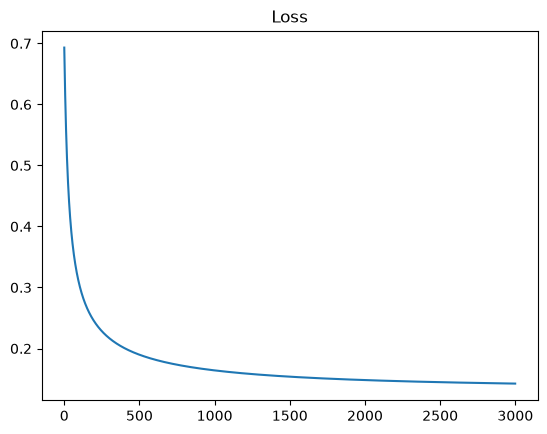

In [14]:
plt.plot(losses)
plt.title('Loss')
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

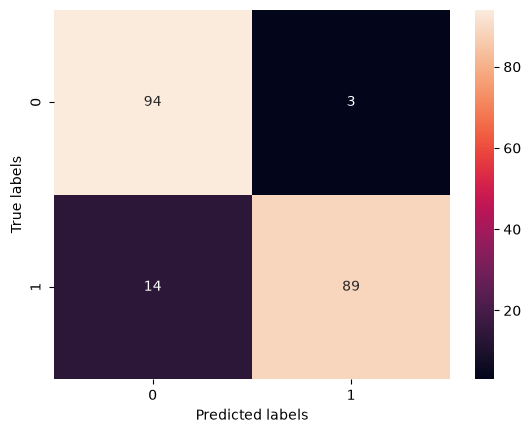

In [15]:
show_confusion_matrix(y_test, y_pred)

### KNN Classifier

In [16]:
from ml_code.models import KNNClassifier

In [17]:
model = KNNClassifier(n_neighbors=5)
model

KNNClassifier(
    n_neighbors=5,
    trained=False
)

In [18]:
model.train(x_train, y_train)
y_pred = model(x_test)

In [19]:
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.895
F1: 0.8951778747607609


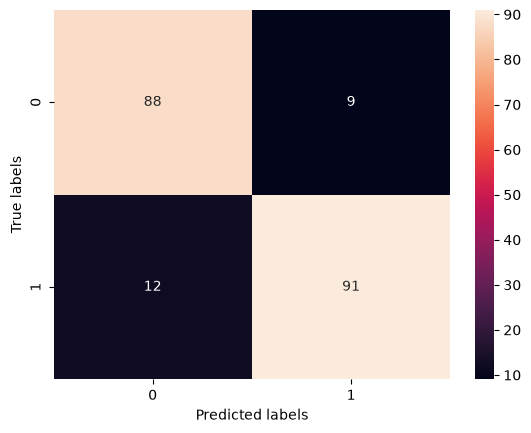

In [20]:
show_confusion_matrix(y_test, y_pred)

In [21]:
# multiclass
x, y = make_classification(n_samples=1000, n_features=10, n_classes=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

In [22]:
model.train(x_train, y_train)
y_pred = model(x_test)

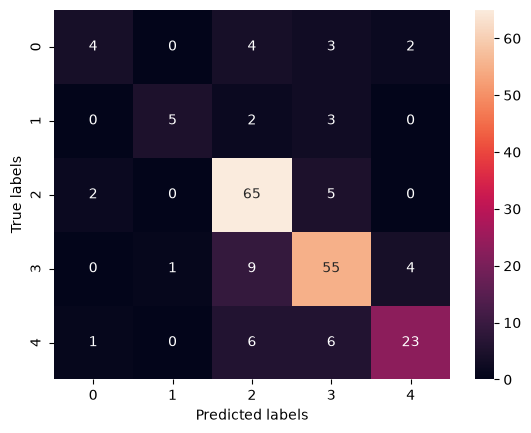

In [23]:
show_confusion_matrix(y_test, y_pred)

### Decision Trees

In [24]:
from ml_code.models import DecisionTreeClassifier

In [25]:
x, y = make_classification(n_samples=500, n_features=3, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = DecisionTreeClassifier(max_depth=10)
model

DecisionTreeClassifier(
    max_depth=10,
    max_features=all,
    random_thresholds=False,
    trained=False
    seed=None
)

In [26]:
model.train(x_train, y_train)
y_pred = model(x_test)
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.95
F1: 0.9235179304563838


In [27]:
from ml_code.models import DecisionTreeRegressor

In [28]:
x, y = make_regression(n_samples=500, n_features=5, noise_coef=0.1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = DecisionTreeRegressor(max_depth=20)
model

DecisionTreeRegressor(
    max_depth=20,
    max_features=all,
    random_thresholds=False,
    trained=False
    seed=None
)

In [29]:
model.train(x_train, y_train)
y_pred = model(x_test)

R-squared: 0.7136345581089184


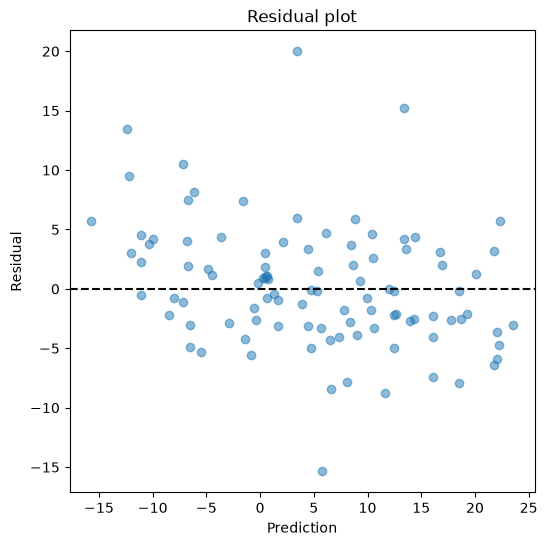

In [30]:
plt.figure(figsize=(6, 6))
resids = y_test - y_pred
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r_squared(y_test, y_pred))

### VotingClassifier, VotingRegressor

In [31]:
from ml_code.models import VotingClassifier

In [32]:
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = VotingClassifier([
    LogisticRegression(),
    KNNClassifier()
])

model

VotingClassifier(
    models=['LogisticRegression', 'KNNClassifier'],
    trained=False
)

In [33]:
model.train(x_train, y_train)
y_pred = model(x_test)

In [34]:
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.905
F1: 0.9087322722368295


In [35]:
from ml_code.models import VotingRegressor

In [36]:
x, y = make_regression(n_samples=1000, n_features=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = VotingRegressor([
    LinearRegression()
])

model

VotingRegressor(
    models=['LinearRegression'],
    trained=False
)

In [37]:
model.train(x_train, y_train)
y_pred = model(x_test)

In [38]:
print("R-squared:", r_squared(y_test, y_pred))

R-squared: 0.961885505523459


### BaggingClassifier, BaggingRegressor

In [39]:
from ml_code.models import BaggingClassifier

In [40]:
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = BaggingClassifier(
    model=KNNClassifier(),
    n_models=5,
    samples=0.75
)

model

BaggingClassifier(
    model=KNNClassifier,
    n_models=5,
    samples=0.75,
    trained=False,
    seed=None
)

In [41]:
model.train(x_train, y_train)
y_pred = model(x_test)

print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.905
F1: 0.9055636303643928


In [42]:
from ml_code.models import BaggingRegressor

In [43]:
x, y = make_regression(n_samples=1000, n_features=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = BaggingRegressor(
    model=LinearRegression(),
    n_models=15,
    samples=0.5
)

model

BaggingRegressor(
    model=LinearRegression,
    n_models=15,
    samples=0.5,
    trained=False,
    seed=None
)

In [44]:
model.train(x_train, y_train)
y_pred = model(x_test)
print("R-squared:", r_squared(y_test, y_pred))

R-squared: 0.9604824063969823


### Random Forest

In [45]:
from ml_code.models import RandomForestClassifier

In [46]:
x, y = make_classification(n_samples=500, n_features=3, n_classes=2, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = RandomForestClassifier(n_models=5)
model

RandomForestClassifier(
    n_models=5,
    max_depth=5,
    trained=False,
    seed=None
)

In [47]:
model.train(x_train, y_train)
y_pred = model(x_test)

print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.91
F1: 0.850315372255647


In [48]:
from ml_code.models import RandomForestRegressor

In [49]:
x, y = make_regression(n_samples=500, n_features=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

model = RandomForestRegressor(n_models=50, max_depth=15)
model

RandomForestRegressor(
    n_models=50,
    max_depth=15,
    trained=False,
    seed=None
)

In [50]:
model.train(x_train, y_train)

R-squared: 0.8687650070079174


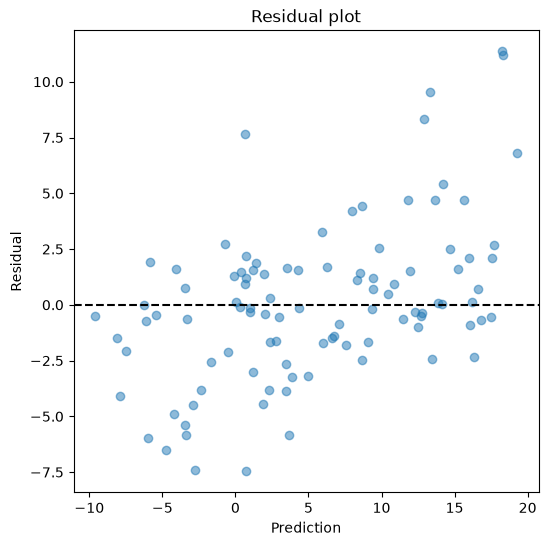

In [51]:
y_pred = model(x_test)
resids = y_test - y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r_squared(y_test, y_pred))

### Extremely Randomized Trees (ExtraTrees)

In [52]:
from ml_code.models import ExtraTreesClassifier

In [53]:
model = ExtraTreesClassifier(n_models=5)
model

ExtraTreesClassifier(
    n_models=5,
    max_depth=5,
    trained=False,
    seed=None
)

In [54]:
model.train(x_train, y_train)
y_pred = model(x_test)

print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.0
F1: 0.0


In [55]:
from ml_code.models import ExtraTreesRegressor

In [56]:
model = ExtraTreesRegressor(n_models=200, max_depth=15)
model

ExtraTreesRegressor(
    n_models=200,
    max_depth=15,
    trained=False,
    seed=None
)

In [57]:
x, y = make_regression(n_samples=500, n_features=5, noise_coef=1, seed=42)
x_train, x_test, y_train, y_test = random_split(x, y, test_size=0.2, seed=42)

R-squared: 0.9015710255234733


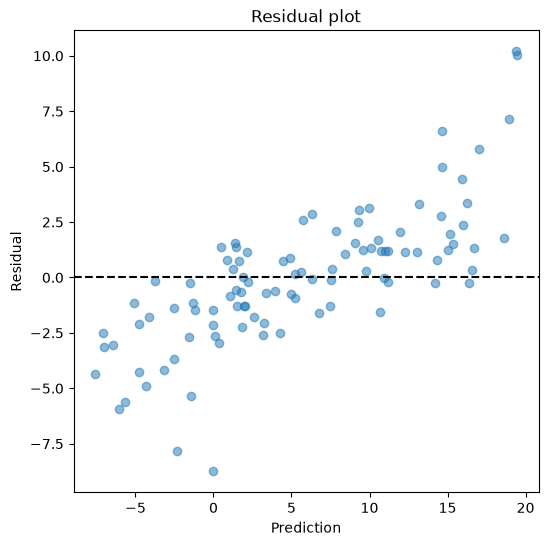

In [58]:
model.train(x_train, y_train)
y_pred = model(x_test)
resids = y_test - y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r_squared(y_test, y_pred))

## Pipeline

In [59]:
from ml_code.pipeline import Pipeline

x, y = make_regression()
x_train, x_test, y_train, y_test = random_split(x, y)

In [60]:
# preprocessing only

pipe_prep = Pipeline([
    StandardScaler(),
    PolynomialFeatures(degree=2)
])

pipe_prep.fit(x_train) # returns None
x_test_processed = pipe_prep(x_test) # returns processed data

In [61]:
# preprocessing + training model

pipe_full = Pipeline([
    StandardScaler(),
    PolynomialFeatures(degree=2),
    LinearRegression()
])

losses = pipe_full.fit(x_train, y_train) # returns losses
y_pred = pipe_full(x_test) # returns predictions
print("R-squared:", r_squared(y_test, y_pred))

R-squared: 0.793794688778927
